# English to Urdu Dataset Statistics

This notebook analyzes the English to Urdu translation dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

# Set style for plots
try:
    plt.style.use('seaborn-v0_8')
except:
    try:
        plt.style.use('seaborn')
    except:
        pass
sns.set_palette("husl")

In [2]:
# Load the dataset (project root = repo root or parent of notebooks/)
PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
dataset_path = PROJECT_ROOT / 'data' / 'english_to_urdu_dataset.xlsx'
df = pd.read_excel(dataset_path)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!
Shape: (9103, 2)

Column names: ['eng', 'urdu']

First few rows:


,eng,urdu
0,the book of the generation of jesus christ the son of david the son of abraham,یسوع مسیح ابن داود ابن ابرہام کا نسب نامہ
1,abraham begat isaac and isaac begat jacob and jacob begat judas and his brethren,ابراہام سے اضحاق پیدا ہوا اور اضحاق سے یعقوب پیدا ہوا اور یعقوب سے یہوداہ اور اس کے بھائی پیدا ہ...
2,and judas begat phares and zara of thamar and phares begat esrom and esrom begat aram,اور یہوداہ سے فارص اور زارح تمر سے پیدا ہوئے اور فارص سے حصرون پیدا ہوا اور حصرون سے رام پیدا ہوا ۔
3,and aram begat aminadab and aminadab begat naasson and naasson begat salmon,اور رام سے عمینداب پیدا ہوا اور عمینداب سے نحسون پیدا ہوا اور نحسون سے سلمون پیدا ہوا ۔
4,and salmon begat booz of rachab and booz begat obed of ruth and obed begat jesse,اور سلمون سے بوعز راحب سے پیدا ہوا اور بوعز سے عوبید روت سے پیدا ہوا اور عوبید سے یسّی پیدا ہوا ۔


In [3]:
# Basic dataset information
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nTotal number of rows: {len(df):,}")
print(f"Total number of columns: {len(df.columns)}")
print(f"\nColumn names and data types:")
print(df.dtypes)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

DATASET OVERVIEW

Total number of rows: 9,103
Total number of columns: 2

Column names and data types:
eng     object
urdu    object
dtype: object

Memory usage: 3.59 MB


In [4]:
# Check for missing values
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing Count': missing_data.values,
    'Missing Percentage': missing_percent.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print("\nColumns with missing values:")
    print(missing_df.to_string(index=False))
else:
    print("\n✓ No missing values found in the dataset!")

MISSING VALUES ANALYSIS

Columns with missing values:
Column  Missing Count  Missing Percentage
  urdu              1            0.010985


In [5]:
# Check for duplicate rows
print("=" * 80)
print("DUPLICATE ROWS ANALYSIS")
print("=" * 80)
duplicate_count = df.duplicated().sum()
print(f"\nTotal duplicate rows: {duplicate_count:,}")
print(f"Percentage of duplicates: {(duplicate_count / len(df)) * 100:.2f}%")

if duplicate_count > 0:
    print("\nSample duplicate rows:")
    print(df[df.duplicated(keep=False)].head(10))
else:
    print("\n✓ No duplicate rows found!")

DUPLICATE ROWS ANALYSIS

Total duplicate rows: 9
Percentage of duplicates: 0.10%

Sample duplicate rows:
                                                                                                      eng  \
78                             that it might be fulfilled which was spoken by esaias the prophet  saying    
179   for every one that asketh receiveth  and he that seeketh findeth  and to him that knocketh it sh...   
320                                             and blessed is he  whosoever shall not be offended in me    
361                            that it might be fulfilled which was spoken by esaias the prophet  saying    
1437                                            where their worm dieth not  and the fire is not quenched    
1439                                            where their worm dieth not  and the fire is not quenched    
2073                                            and blessed is he  whosoever shall not be offended in me    
2270  for every one tha

In [6]:
# Statistical summary for numeric columns
print("=" * 80)
print("NUMERIC COLUMNS STATISTICS")
print("=" * 80)
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    print("\nStatistical Summary:")
    print(df[numeric_cols].describe())
else:
    print("\nNo numeric columns found in the dataset.")

NUMERIC COLUMNS STATISTICS

No numeric columns found in the dataset.


In [7]:
# Text statistics (assuming English and Urdu columns exist)
print("=" * 80)
print("TEXT STATISTICS")
print("=" * 80)

# Identify text columns (usually object/string type)
text_cols = df.select_dtypes(include=['object']).columns

for col in text_cols:
    print(f"\n--- Statistics for '{col}' column ---")
    
    # Calculate text length statistics
    text_lengths = df[col].astype(str).str.len()
    
    print(f"Total entries: {df[col].notna().sum():,}")
    print(f"Average length: {text_lengths.mean():.2f} characters")
    print(f"Median length: {text_lengths.median():.2f} characters")
    print(f"Min length: {text_lengths.min()} characters")
    print(f"Max length: {text_lengths.max()} characters")
    print(f"Std deviation: {text_lengths.std():.2f} characters")
    
    # Word count statistics (if applicable)
    word_counts = df[col].astype(str).str.split().str.len()
    print(f"\nAverage words per entry: {word_counts.mean():.2f}")
    print(f"Median words per entry: {word_counts.median():.2f}")
    print(f"Min words: {word_counts.min()}")
    print(f"Max words: {word_counts.max()}")
    
    # Show sample entries
    print(f"\nSample entries:")
    sample_entries = df[col].dropna().head(5)
    for idx, entry in enumerate(sample_entries, 1):
        print(f"  {idx}. {str(entry)[:100]}...")

TEXT STATISTICS

--- Statistics for 'eng' column ---
Total entries: 9,103
Average length: 107.25 characters
Median length: 105.00 characters
Min length: 3 characters
Max length: 361 characters
Std deviation: 50.70 characters

Average words per entry: 20.61
Median words per entry: 20.00
Min words: 1
Max words: 68

Sample entries:
  1. the book of the generation of jesus christ  the son of david  the son of abraham ...
  2. abraham begat isaac  and isaac begat jacob  and jacob begat judas and his brethren ...
  3. and judas begat phares and zara of thamar  and phares begat esrom  and esrom begat aram ...
  4. and aram begat aminadab  and aminadab begat naasson  and naasson begat salmon ...
  5. and salmon begat booz of rachab  and booz begat obed of ruth  and obed begat jesse ...

--- Statistics for 'urdu' column ---
Total entries: 9,102
Average length: 95.45 characters
Median length: 93.00 characters
Min length: 3 characters
Max length: 333 characters
Std deviation: 44.14 characters

Av

VISUALIZATIONS


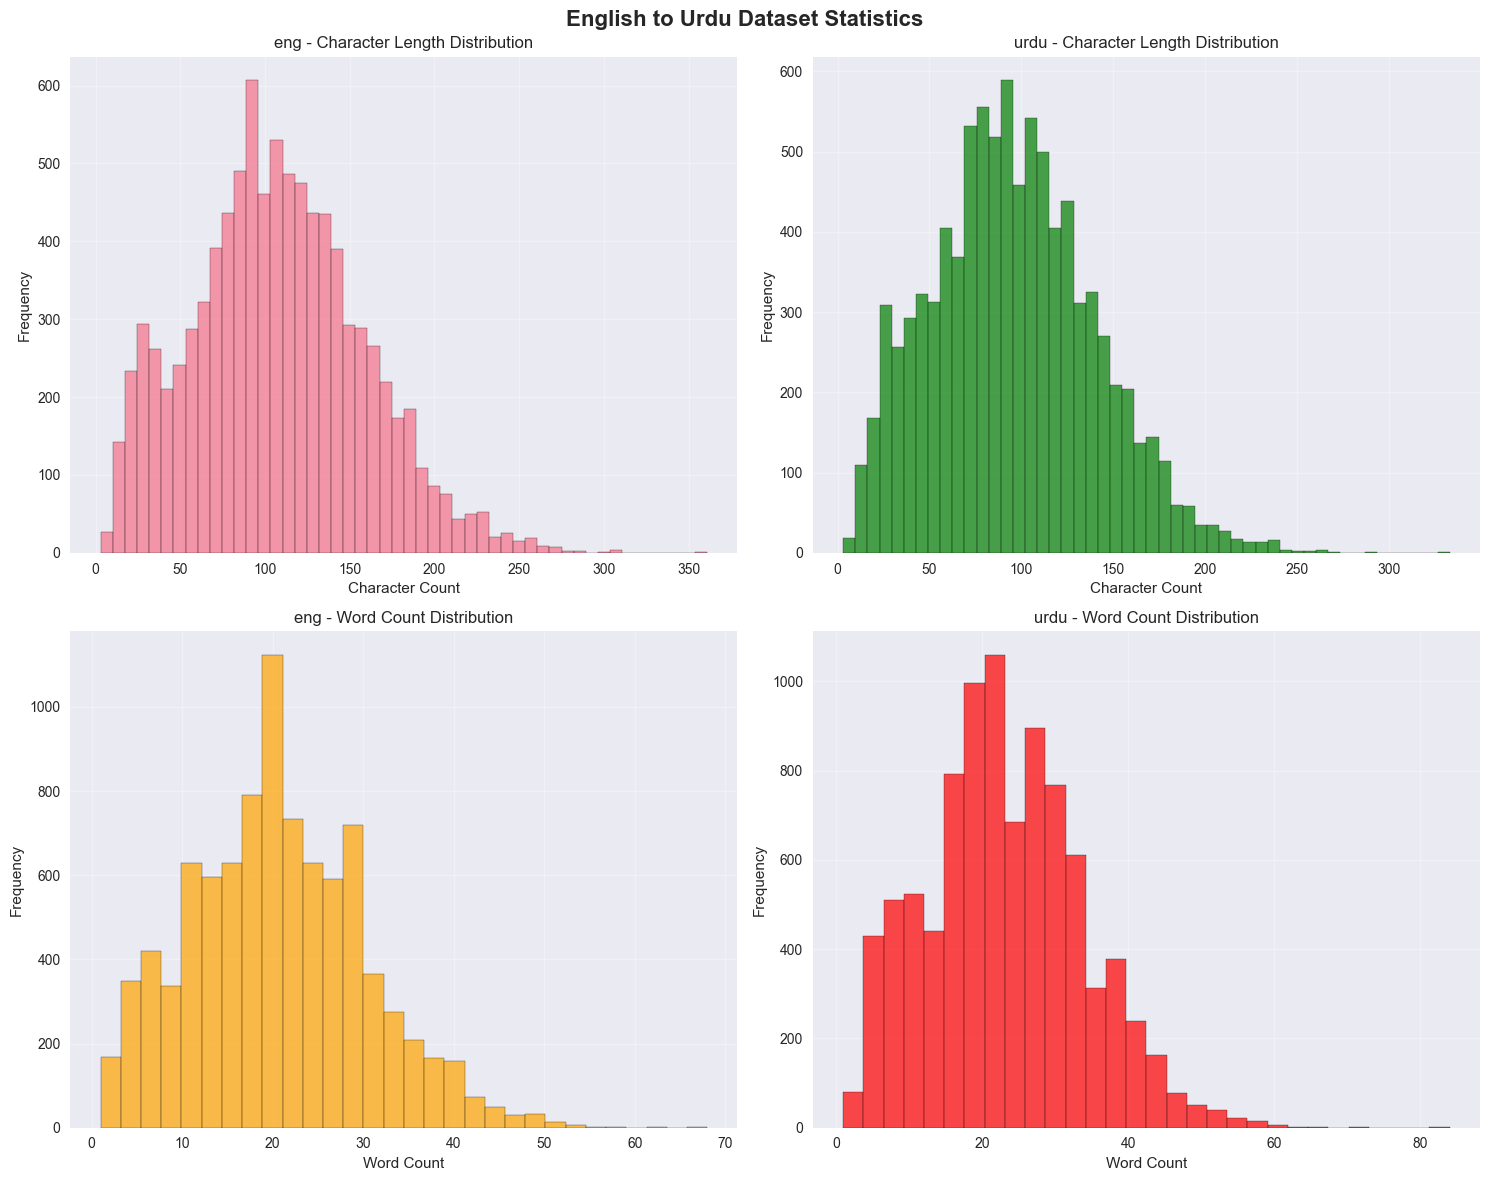

In [8]:
# Visualizations
print("=" * 80)
print("VISUALIZATIONS")
print("=" * 80)

# Identify text columns for visualization
text_cols = df.select_dtypes(include=['object']).columns

if len(text_cols) >= 2:
    # Assume first two text columns are English and Urdu
    eng_col = text_cols[0]
    urdu_col = text_cols[1]
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('English to Urdu Dataset Statistics', fontsize=16, fontweight='bold')
    
    # 1. Text length distribution for English
    eng_lengths = df[eng_col].astype(str).str.len()
    axes[0, 0].hist(eng_lengths, bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title(f'{eng_col} - Character Length Distribution')
    axes[0, 0].set_xlabel('Character Count')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Text length distribution for Urdu
    urdu_lengths = df[urdu_col].astype(str).str.len()
    axes[0, 1].hist(urdu_lengths, bins=50, edgecolor='black', alpha=0.7, color='green')
    axes[0, 1].set_title(f'{urdu_col} - Character Length Distribution')
    axes[0, 1].set_xlabel('Character Count')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Word count distribution for English
    eng_words = df[eng_col].astype(str).str.split().str.len()
    axes[1, 0].hist(eng_words, bins=30, edgecolor='black', alpha=0.7, color='orange')
    axes[1, 0].set_title(f'{eng_col} - Word Count Distribution')
    axes[1, 0].set_xlabel('Word Count')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Word count distribution for Urdu
    urdu_words = df[urdu_col].astype(str).str.split().str.len()
    axes[1, 1].hist(urdu_words, bins=30, edgecolor='black', alpha=0.7, color='red')
    axes[1, 1].set_title(f'{urdu_col} - Word Count Distribution')
    axes[1, 1].set_xlabel('Word Count')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
elif len(text_cols) == 1:
    # Single text column visualization
    col = text_cols[0]
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'{col} Column Statistics', fontsize=16, fontweight='bold')
    
    lengths = df[col].astype(str).str.len()
    words = df[col].astype(str).str.split().str.len()
    
    axes[0].hist(lengths, bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_title('Character Length Distribution')
    axes[0].set_xlabel('Character Count')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].hist(words, bins=30, edgecolor='black', alpha=0.7, color='green')
    axes[1].set_title('Word Count Distribution')
    axes[1].set_xlabel('Word Count')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No text columns found for visualization.")

COMPARISON BETWEEN ENGLISH AND URDU COLUMNS

Comparison Table:
                  Metric        eng      urdu  Ratio (Urdu/English)
Average Character Length 107.253982 95.449962              0.889943
 Median Character Length 105.000000 93.000000              0.885714
      Average Word Count  20.612545 23.139734              1.122604
       Median Word Count  20.000000 23.000000              1.150000


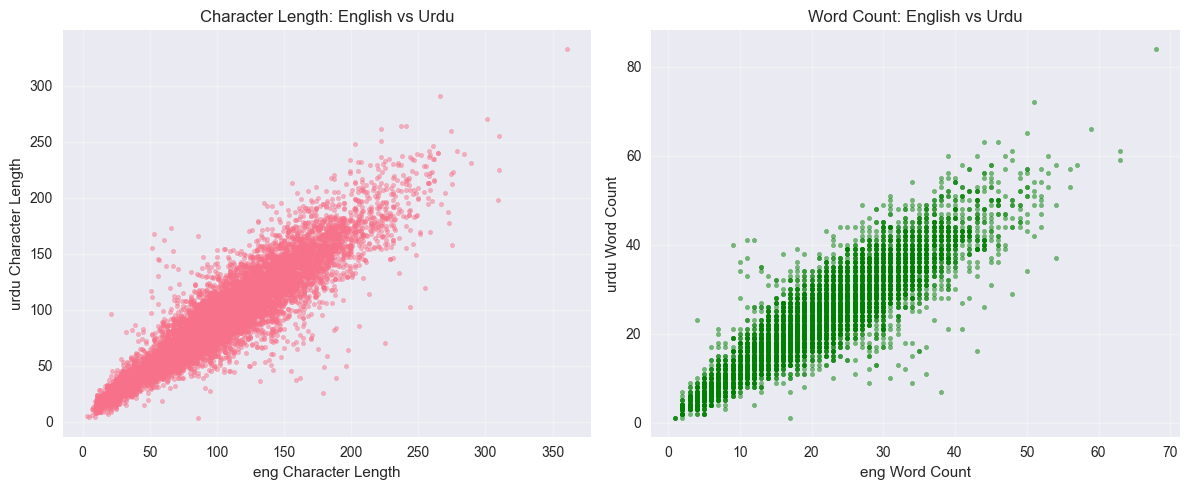

In [9]:
# Comparison between English and Urdu (if both columns exist)
text_cols = df.select_dtypes(include=['object']).columns

if len(text_cols) >= 2:
    eng_col = text_cols[0]
    urdu_col = text_cols[1]
    
    print("=" * 80)
    print("COMPARISON BETWEEN ENGLISH AND URDU COLUMNS")
    print("=" * 80)
    
    eng_lengths = df[eng_col].astype(str).str.len()
    urdu_lengths = df[urdu_col].astype(str).str.len()
    eng_words = df[eng_col].astype(str).str.split().str.len()
    urdu_words = df[urdu_col].astype(str).str.split().str.len()
    
    comparison_df = pd.DataFrame({
        'Metric': ['Average Character Length', 'Median Character Length', 
                   'Average Word Count', 'Median Word Count'],
        eng_col: [eng_lengths.mean(), eng_lengths.median(), 
                  eng_words.mean(), eng_words.median()],
        urdu_col: [urdu_lengths.mean(), urdu_lengths.median(), 
                   urdu_words.mean(), urdu_words.median()]
    })
    
    comparison_df['Ratio (Urdu/English)'] = comparison_df[urdu_col] / comparison_df[eng_col]
    
    print("\nComparison Table:")
    print(comparison_df.to_string(index=False))
    
    # Scatter plot: English vs Urdu length
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(eng_lengths, urdu_lengths, alpha=0.5, s=10)
    plt.xlabel(f'{eng_col} Character Length')
    plt.ylabel(f'{urdu_col} Character Length')
    plt.title('Character Length: English vs Urdu')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.scatter(eng_words, urdu_words, alpha=0.5, s=10, color='green')
    plt.xlabel(f'{eng_col} Word Count')
    plt.ylabel(f'{urdu_col} Word Count')
    plt.title('Word Count: English vs Urdu')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [10]:
# Display sample data
print("=" * 80)
print("SAMPLE DATA")
print("=" * 80)
print("\nFirst 10 rows:")
print(df.head(10).to_string())
print("\n\nLast 10 rows:")
print(df.tail(10).to_string())
print("\n\nRandom 5 rows:")
print(df.sample(5).to_string())

SAMPLE DATA

First 10 rows:
                                                                                                        eng                                                                                                    urdu
0                         the book of the generation of jesus christ  the son of david  the son of abraham                                                                یسوع مسیح ابن داود ابن ابرہام کا نسب نامہ
1                       abraham begat isaac  and isaac begat jacob  and jacob begat judas and his brethren    ابراہام سے اضحاق پیدا ہوا اور اضحاق سے یعقوب پیدا ہوا اور یعقوب سے یہوداہ اور اس کے بھائی پیدا ہوئے ۔
2                  and judas begat phares and zara of thamar  and phares begat esrom  and esrom begat aram      اور یہوداہ سے فارص اور زارح تمر سے پیدا ہوئے اور فارص سے حصرون پیدا ہوا اور حصرون سے رام پیدا ہوا ۔
3                            and aram begat aminadab  and aminadab begat naasson  and naasson begat salmon                  

In [ ]:
# Summary statistics
print("=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)
print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Total Data Points: {df.shape[0] * df.shape[1]:,}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Duplicate Rows: {df.duplicated().sum():,}")
print(f"Missing Values: {df.isnull().sum().sum():,}")

text_cols = df.select_dtypes(include=['object']).columns
if len(text_cols) > 0:
    print(f"\nText Columns: {', '.join(text_cols)}")
    for col in text_cols:
        avg_len = df[col].astype(str).str.len().mean()
        avg_words = df[col].astype(str).str.split().str.len().mean()
        print(f"  - {col}: Avg length={avg_len:.1f} chars, Avg words={avg_words:.1f}")

print("\nAnalysis complete!")

SUMMARY STATISTICS

Dataset Shape: 9,103 rows × 2 columns
Total Data Points: 18,206
Memory Usage: 3.59 MB
Duplicate Rows: 9
Missing Values: 1

Text Columns: eng, urdu
  - eng: Avg length=107.3 chars, Avg words=20.6
  - urdu: Avg length=95.4 chars, Avg words=23.1

✓ Analysis complete!
